# Fraud Date Delta: how long should you wait before trusting a "not fraud" label?

This notebook builds the date-delta concept described in the companion [README](README.md):
for every transaction, fraud is not known instantly, it is *reported* some
number of days later. That reporting lag means a fraud label is only as
trustworthy as the observation window behind it. We measure that lag, find
an observation window ("date delta") that captures fraud without waiting
forever, and show two ways of using it, only one of which is safe.

No model is trained here on purpose: this is a labelling-strategy
notebook, the point is the descriptions, the counts and the plots.

#### Configuration

In [1]:
from __future__ import annotations

import io
import urllib.request
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from date_delta_analysis import FraudDateDeltaAnalyzer, add_synthetic_fraud_fields

# ── Random state ────────────────────────────────────────────────────────────
SEED = 45

# ── Synthetic label / fraud-date generation ────────────────────────────────
FRAUD_RATE   = 0.01   # 1 % of rows are (synthetically) fraud
MIN_LAG_DAYS = 1
MAX_LAG_DAYS = 180
LAG_SCALE    = 50.0   # shifted-exponential scale: quick to spot, long tail

# ── Kaggle source dataset ───────────────────────────────────────────────────
KAGGLE_DATASET_URL = (
    "https://www.kaggle.com/api/v1/datasets/download/"
    "valakhorasani/bank-transaction-dataset-for-fraud-detection"
)


---
## 1. The dataset

[Bank Transaction Dataset for Fraud Detection](https://www.kaggle.com/datasets/valakhorasani/bank-transaction-dataset-for-fraud-detection)
(Kaggle, by Valentina Khorasani) — 2,512 bank transactions with amounts,
channels, devices, locations and a `TransactionDate`. It ships with **no
fraud label at all**, which is convenient here: it means every property of
the label used below is one we deliberately put there, nothing is hidden
inside a pre-existing column.

The download works anonymously through Kaggle's public API endpoint, no
API key required for this dataset.

In [2]:
request = urllib.request.Request(KAGGLE_DATASET_URL, headers={"User-Agent": "Mozilla/5.0"})
with urllib.request.urlopen(request, timeout=30) as response:
    archive_bytes = response.read()

with zipfile.ZipFile(io.BytesIO(archive_bytes)) as archive:
    csv_name = archive.namelist()[0]
    with archive.open(csv_name) as f:
        raw_df = pd.read_csv(f, parse_dates=["TransactionDate", "PreviousTransactionDate"])

print(f"{len(raw_df):,} transactions  |  {raw_df['TransactionDate'].min().date()} → {raw_df['TransactionDate'].max().date()}")
raw_df.head(3)


2,512 transactions  |  2023-01-02 → 2024-01-01


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04


---
## 2. Adding the two synthetic fields

Two fields get added, both fully reproducible from `SEED`:

1. **`IsFraud`** — exactly 1 % of rows, chosen with `rng.choice(..., replace=False)`.
   Using `choice` on the row positions (rather than `rng.random() < rate`) pins the
   *count* down exactly, not just its expectation.
2. **`FraudReportedDate`** — for fraud rows only, `TransactionDate + lag`, where
   `lag` is drawn from a shifted exponential distribution (`min_lag_days` floor,
   `max_lag_days` ceiling). This models a realistic reporting pattern: most fraud
   is flagged quickly, a minority takes much longer.

Both draws come from the same seeded `numpy.random.Generator`, so re-running this
cell (or the whole notebook) always reproduces the same labels and the same
dates.

In [3]:
df = add_synthetic_fraud_fields(
    raw_df,
    fraud_rate=FRAUD_RATE,
    min_lag_days=MIN_LAG_DAYS,
    max_lag_days=MAX_LAG_DAYS,
    lag_scale=LAG_SCALE,
    seed=SEED,
)

n_fraud = int(df["IsFraud"].sum())
print(f"Fraud count : {n_fraud} / {len(df):,}  ->  ratio = {n_fraud / len(df):.3%}")

df.loc[df["IsFraud"] == 1, ["TransactionID", "TransactionDate", "FraudReportedDate"]].head()


Fraud count : 25 / 2,512  ->  ratio = 0.995%


,TransactionID,TransactionDate,FraudReportedDate
300,TX000301,2023-11-21 16:23:41,2023-11-24 16:23:41
705,TX000706,2023-12-12 16:17:27,2023-12-20 16:17:27
1023,TX001024,2023-09-08 16:28:54,2023-11-07 16:28:54
1058,TX001059,2023-07-25 18:04:46,2023-08-08 18:04:46
1274,TX001275,2023-10-12 16:29:49,2023-10-13 16:29:49


---
## 3. How long does it take to spot fraud?

`FraudDateDeltaAnalyzer` takes the labelled dataframe and computes, for every
fraud row, the **date delta**: `FraudReportedDate - TransactionDate`, in days.

count     25.000000
mean      34.320000
std       29.539127
min        1.000000
25%       14.000000
50%       26.000000
75%       42.000000
max      127.000000
Name: _date_delta_days, dtype: float64


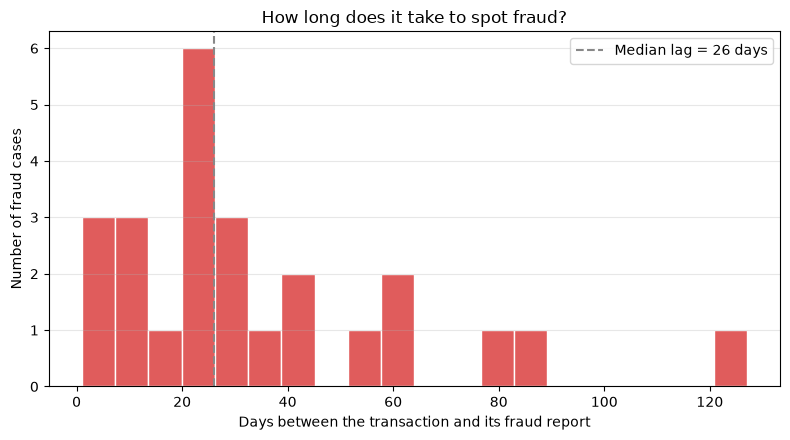

In [4]:
analyzer = FraudDateDeltaAnalyzer(
    df.sort_values("TransactionDate"),
    transaction_date_col="TransactionDate",
    fraud_date_col="FraudReportedDate",
    label_col="IsFraud",
)

deltas = analyzer.fraud_deltas
print(deltas.describe())

fig = analyzer.plot_delta_distribution()
fig.savefig("img/delta_distribution.png", dpi=150, bbox_inches="tight")


The distribution is skewed exactly as designed: half of all fraud is reported
within about a month, but the tail stretches out past four months. A single
"days since transaction" cutoff, chosen carelessly, will either miss that
tail (too short) or throw away most of the dataset waiting for it (too
long).

---
## 4. Finding the optimal date delta

Here is the rule from the README, spelled out: order transactions by date,
call `reference_date` the last transaction date in the data. For a candidate
window of `d` days:

* a transaction only counts as **mature** for `d` if it happened at least
  `d` days before `reference_date` — anything more recent hasn't had the
  full `d` days to be reported yet, so we cannot yet say whether it would
  have counted;
* among mature transactions, a fraud is **captured** at `d` if it was
  reported within `d` days of the transaction.

Growing `d` helps (a longer window catches fraud reported later) and hurts
(the mature pool shrinks, because the most recent `d` days of transactions
keep getting excluded) at the same time. In general, that tension gives the
curve a genuine shape, not just noise: it climbs while short windows are
still missing most of the reporting-lag distribution, and it comes back
down once the window is wide enough that shrinking the mature pool further
costs more mature frauds than the extra lag tolerance still buys. **It goes
up, then down** — a real peak, not a plateau you can extend for free.

Several candidate values of `d` can tie for that peak. The **optimal date
delta** is deliberately the *smallest* `d` that reaches it: a larger, tied
`d` would capture exactly the same fraud while discarding strictly more
mature transactions for nothing in return, so the earliest one always wins,
never just as an arbitrary tie-break.

Optimal date delta : 60 days


,date_delta_days,mature_transactions,captured_frauds,captured_fraud_rate
0,1,2499,1,0.000400
59,60,2085,17,0.008153
126,127,1590,12,0.007547


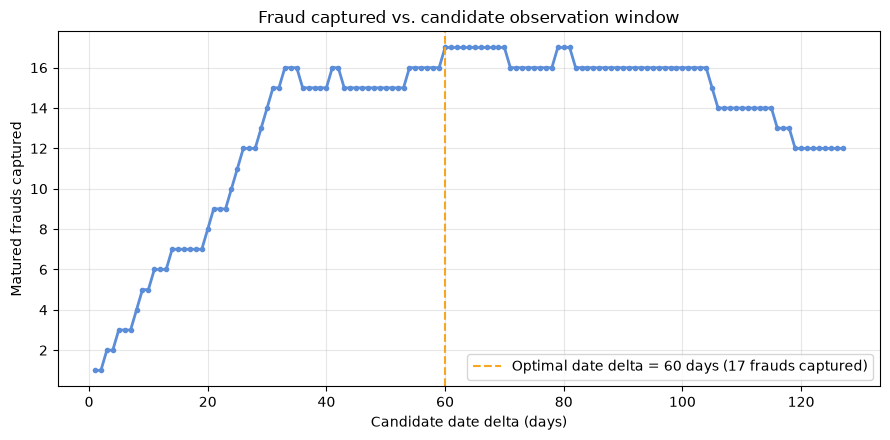

In [5]:
curve = analyzer.compute_maturity_curve()
fig, optimal_day = analyzer.plot_maturity_curve()
fig.savefig("img/maturity_curve.png", dpi=150, bbox_inches="tight")

print(f"Optimal date delta : {optimal_day} days")
curve.iloc[[0, optimal_day - 1, -1]]


At `d = 1` almost nothing is captured yet (fraud simply hasn't had time to
be reported). The curve climbs steeply, flattens into a plateau once most
of the reporting-lag distribution's mass is already inside the window, and
gently drifts down past it, exactly the up-then-down shape Section 4
described. It even touches its own peak value a second time much further
out (the flat stretch after day 79): reaching the same 17 captured frauds
there, at the cost of over 150 extra dropped transactions, is exactly why
"earliest tied `d` wins" is a rule and not a suggestion.

In [6]:
# The marginal cost of chasing the last captured fraud
milestones = analyzer.compute_capture_milestones()
milestones


,date_delta_days,mature_transactions,captured_frauds,captured_fraud_rate,transactions_dropped
0,1,2499,1,0.000400,13
1,3,2498,2,0.000801,14
2,5,2482,3,0.001209,30
3,8,2448,4,0.001634,64
4,9,2448,5,0.002042,64
5,11,2439,6,0.002460,73
6,14,2413,7,0.002901,99
7,20,2385,8,0.003354,127
8,21,2377,9,0.003786,135
9,24,2361,10,0.004235,151


Each row above is a new record: the earliest `d` at which a wider window
first captured more fraud than any narrower one had so far. The
`transactions_dropped` column is what that record actually cost. Early
records are cheap, a handful of extra dropped rows buys several extra
frauds. The last one rarely is: going from the second-best count to the
global optimum here drops nearly as many transactions on its own as every
earlier milestone combined, to capture exactly one more fraud case.

That is the trade-off worth making explicit rather than automating away:
`get_optimal_date_delta` will always hand back the strict, global best, and
that is the right default. But a team that finds the last row's price tag
too steep for one label is not wrong to instead pick the second-to-last
milestone and accept a slightly smaller `d` — as long as that choice is
made on purpose, and the resulting window is applied consistently
afterwards.

---
## 5. Turning a date delta into a label — two ways, only one is safe

Picking `optimal_day` answers "how many days of lag should the label
definition tolerate?". Applying that choice to the training data can be done
two ways:

1. **Discard the immature tail (recommended)** — drop every transaction from
   the last `optimal_day` days of the dataset, because we genuinely don't
   know yet whether they will turn into fraud within the window. Everything
   that remains has had the full window to be reported, so its label,
   fraud or not, can be trusted.
2. **Relabel and keep everything** — keep the immature tail too, and simply
   mark anything not (yet) reported as fraud as legitimate (`0`).

Both behaviours also relabel fraud reported *later* than `optimal_day` days
as `0` — that part is just enforcing the window's own definition of fraud
consistently. The difference between the two is entirely about the
transactions that are too recent to have finished the observation window.

`FraudDateDeltaAnalyzer.apply_date_delta_window(date_delta_days, discard_immature=...)`
implements both behind that one flag.

In [7]:
strict_df  = analyzer.apply_date_delta_window(optimal_day, discard_immature=True)
relabel_df = analyzer.apply_date_delta_window(optimal_day, discard_immature=False)

def summarize(name, before, after):
    n_before, fraud_before = len(before), int(before["IsFraud"].sum())
    n_after, fraud_after = len(after), int(after["IsFraud"].sum())
    print(f"{name}")
    print(f"  rows        : {n_before:,} -> {n_after:,}  ({n_before - n_after:,} dropped)")
    print(f"  fraud count : {fraud_before} -> {fraud_after}")
    print(f"  fraud ratio : {fraud_before / n_before:.3%} -> {fraud_after / n_after:.3%}")
    print()

summarize("Discard immature tail (recommended)", df, strict_df)
summarize("Relabel and keep everything",         df, relabel_df)


Discard immature tail (recommended)
  rows        : 2,512 -> 2,085  (427 dropped)
  fraud count : 25 -> 17
  fraud ratio : 0.995% -> 0.815%

Relabel and keep everything
  rows        : 2,512 -> 2,512  (0 dropped)
  fraud count : 25 -> 21
  fraud ratio : 0.995% -> 0.836%



`discard_immature=True` drops rows but never lies about a label: every row
left in `strict_df` has had the full `optimal_day`-day window to be reported,
so `IsFraud == 0` there means "observed for long enough, and still clean".
The 427 dropped rows include 4 transactions that were already confirmed
fraud, just too recently for the 60-day window to have fully elapsed —
that is the real cost of being conservative, a handful of otherwise-usable
positive labels thrown out along with the rest of the tail.

`discard_immature=False` keeps the same row count as the original data,
immature tail included. That recovers those 4 frauds (`IsFraud` goes from
17 up to 21), but it also keeps the other 421 dropped rows, transactions
that simply haven't had 60 days to be reported yet, and labels every one of
them legitimate by default. None of them happen to have flipped to fraud in
this particular snapshot, but the mode never checked, it would do the exact
same thing whether they had or not. That is the actual risk: nothing about
`discard_immature=False` distinguishes "confirmed clean" from "not yet
resolved", it silently treats the second as the first, for the 421 rows
where it happens to still be true today and for any row, on any other
slice of data, where it might not be.

---
## 6. The takeaway

A fraud definition is a **time-bound** definition — "fraud, if reported
within `d` days" — whether that's made explicit or not. Whatever `d` a team
settles on, consistency requires leaving out the slice of training data that
hasn't yet had `d` days to prove itself, rather than defaulting the unproven
rows to "not fraud". The alternative feels like free extra data; it is
actually label noise concentrated at the exact rows closest to production,
which is the worst possible place for it to hide.

Picking `d` itself is not a one-shot lookup either. The captured-fraud curve
in Section 4 goes up, then down, by construction, not by coincidence, so
"pick the maximum" is well defined but ties should always break toward the
smallest `d` that reaches it. And the maximum itself isn't free: Section 4's
milestone table showed the last fraud captured here costing almost as much
mature data as every earlier one combined. The strict optimum is the right
default, but knowing its price tag is what makes it a decision instead of
just a formula.